## Формулы и постановка задачи

### Простая плоская баллистика без сопротивления:
$$
x(t)=v_0\cos\theta\,t,\qquad y(t)=v_0\sin\theta\,t-\tfrac12 g t^2\\
$$
Для целевой точки (X,Y)получаем неравенство/уравнение:
$$
t=\frac{X}{v_0\cos\theta},\qquad f(\theta)=v_0\sin\theta\,t-\tfrac12 g t^2 - Y =0
$$
Производная (нужна для метода Ньютона):
$$
t(\theta)=\frac{X}{v_0\cos\theta},\quad \frac{dt}{d\theta}=\frac{X}{v_0}\sec\theta\tan\theta,\\
f'(\theta)=v_0\cos\theta\,t + (v_0\sin\theta - g t)\frac{dt}{d\theta}.\\
$$

Полёт в поле двух тел (приближение в плоскости, Земля в начале в нуле):
$$
\ddot{\mathbf r} = -G M_E\frac{\mathbf r}{|\mathbf r|^3} - G M_M\frac{\mathbf r-\mathbf r_M(t)}{|\mathbf r-\mathbf r_M(t)|^3},\\
\text{где }\mathbf r_M(t)\text{ — позиция Луны (здесь возьмём круговую орбиту).}
$$

In [1]:
import numpy as np
from math import sin, cos
from time import perf_counter
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, newton, fsolve, minimize_scalar
from scipy.integrate import solve_ivp


# Гравитационные и астрономические константы (SI)
G = 6.67430e-11
M_e = 5.97219e24 # масса Земли, кг
R_e = 6371e3 # радиус Земли, м
M_m = 7.342e22 # масса Луны, кг
R_m = 1737.4e3 # радиус Луны, м
a_EM = 384_400e3 # среднее расстояние Земля-Луна, м
# угловая скорость Луны при приближённой круговой орбите
omega_m = np.sqrt(G*(M_e+M_m)/a_EM**3)

In [2]:
def f_theta(theta, v0, X, Y, g=9.80665):
    """Возвращает отклонение по высоте для данного угла theta."""
    c = np.cos(theta)
    if abs(c) < 1e-12:
        return np.inf
    t = X/(v0*c)
    y = v0*np.sin(theta)*t - 0.5*g*t*t
    return y - Y


def df_theta(theta, v0, X, Y, g=9.80665):
    c = np.cos(theta)
    s = np.sin(theta)
    if abs(c) < 1e-12:
        return np.nan
    t = X/(v0*c)
    dt_dtheta = (X/v0) * (1/c) * (s/c) # X/v0 * sec * tan
    return v0*c*t + (v0*s - g*t) * dt_dtheta


# Функция для построения траектории при заданном угле (без сопротивления)
def trajectory_xy(theta, v0, g=9.80665, tmax=None, n=200):
    c = np.cos(theta); s = np.sin(theta)
    if tmax is None:
        # ориентировочное время полёта до пересечения с землёй
        t_flight = 2*v0*s/g if s>0 else 0.0
        tmax = max(1e-3, t_flight)
    t = np.linspace(0, tmax, n)
    x = v0*c*t
    y = v0*s*t - 0.5*g*t*t
    return t, x, y


# Функции-обёртки для поиска угла: brentq (root_scalar), newton, fsolve
def find_angle_brent(v0, X, Y, bracket=(1e-6, np.pi/2-1e-6)):
    sol = root_scalar(lambda th: f_theta(th, v0, X, Y), bracket=bracket, method='brentq')
    return sol.root, sol.iterations, sol.flag


def find_angle_newton(v0, X, Y, x0=0.3, tol=1e-10, maxiter=50):
    def g(th):
        return f_theta(th, v0, X, Y)
    def gp(th):
        return df_theta(th, v0, X, Y)
    th = newton(g, x0, fprime=gp, tol=tol, maxiter=maxiter)
    return th


def find_angle_fsolve(v0, X, Y, x0=0.3):
    sol = fsolve(lambda th: f_theta(th, v0, X, Y), x0)
    return sol[0]

In [3]:
v0 = 300.0 # м/с
X = 8000.0 # м
Y = 0.0 # м


# Подберём брукет для brentq: функция должна менять знак. Сделаем скан по углам
angles = np.linspace(1e-4, np.pi/2-1e-4, 200)
vals = np.array([f_theta(a, v0, X, Y) for a in angles])
# Найдём интервал, где есть знак изменения
idx = np.where(np.sign(vals[:-1]) != np.sign(vals[1:]))[0]
if len(idx)==0:
# нет очевидной пары — возьмём простую инициализацию (может быть 1 решение)
    bracket = (0.1, 1.0)
else:
    i = idx[0]
    bracket = (angles[i], angles[i+1])


results = {}
# brentq
t0 = perf_counter()
th_brent, iters_brent, flag = find_angle_brent(v0, X, Y, bracket=bracket)
t_brent = perf_counter()-t0
results['brentq'] = (th_brent, t_brent, iters_brent)
# newton
t0 = perf_counter()
try:
    th_newt = find_angle_newton(v0, X, Y, x0=0.5*(bracket[0]+bracket[1]))
    t_newt = perf_counter()-t0
    results['newton'] = (th_newt, t_newt)
except Exception as e:
    results['newton'] = (np.nan, None)
# fsolve
t0 = perf_counter()
th_fs = find_angle_fsolve(v0, X, Y, x0=0.5*(bracket[0]+bracket[1]))
t_fs = perf_counter()-t0
results['fsolve'] = (th_fs, t_fs)

 
# Вывод результатов
print('Результаты поиска угла для v0=%.1f m/s, X=%.1f m, Y=%.1f m' % (v0,X,Y))
for k,v in results.items():
    print(k, v)

Результаты поиска угла для v0=300.0 m/s, X=8000.0 m, Y=0.0 m
brentq (0.5293326645587135, 7.480000022042077e-05, 5)
newton (np.float64(0.5293326645587136), 0.00015620000067428919)
fsolve (np.float64(0.5293326645587132), 0.00016679999953339575)


Text(0.5, 1.0, 'Траектории для найденных углов (простая модель)')

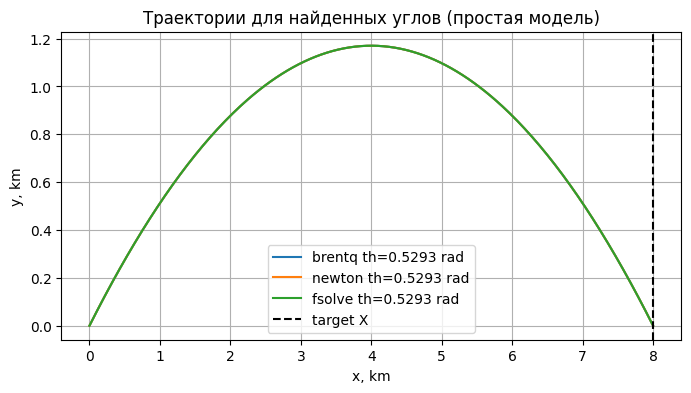

In [4]:
# График траекторий для найденных углов
plt.figure(figsize=(8,4))
for name,info in results.items():
    th = info[0]
    if not np.isfinite(th):
        continue
    t,x,y = trajectory_xy(th, v0, tmax=2*v0*abs(np.sin(th))/9.80665, n=300)
    plt.plot(x/1000, y/1000, label=f"{name} th={th:.4f} rad")
plt.axvline(X/1000, color='k', linestyle='--', label='target X')
plt.xlabel('x, km'); plt.ylabel('y, km'); plt.legend(); plt.grid(True)
plt.title('Траектории для найденных углов (простая модель)')

### Выводы по части 1:
- Метод `brentq` (метод бисекции/брута по отрезку с проверкой знака) стабилен при наличии изменения знака.
- Метод Ньютона быстрый при хорошей начальной догадке и корректной аналитической производной.
- `fsolve` (Nelder–Mead/Levenberg–Marquardt под капотом) удобен, но может требовать хорошей инициализации.

## Часть 2 — "Из пушки на Луну" (двухтелесная модель, подбор начального угла)

### Подход:
- Модель: Земля в начале в начале координат, Луна на круговой орбите радиуса $a_{EM}$.
- Интегрируем систему ODE для снаряда: положения и скорости в декартовой плоскости.
- Для заданной начальной скорости $v_0$ ищем угол запуска (в локальном горизонте) такой, чтобы минимальное расстояние до Луны стало равно радиусу Луны (попадание).

In [5]:
# Позиция Луны в любой момент (примерно круговая орбита)
def moon_pos(t):
    return np.array([a_EM*np.cos(omega_m*t), a_EM*np.sin(omega_m*t)])


# Правая часть для ODE: состояние z = [x, y, vx, vy]
def rhs(t, z):
    x, y, vx, vy = z
    r = np.array([x, y])
    r_m = moon_pos(t)
    # ускорения
    r_norm = np.linalg.norm(r)
    a_e = -G*M_e * r / (r_norm**3)
    r_rel = r - r_m
    a_m = -G*M_m * r_rel / (np.linalg.norm(r_rel)**3)
    ax, ay = a_e + a_m
    return [vx, vy, ax, ay]


# События: попадание в Луну, падение на Землю
def event_hit_moon(t, z):
    r = np.array([z[0], z[1]])
    r_m = moon_pos(t)
    return np.linalg.norm(r - r_m) - R_m
event_hit_moon.terminal = True
event_hit_moon.direction = -1


def event_hit_earth(t, z):
    r = np.array([z[0], z[1]])
    return np.linalg.norm(r) - R_e
event_hit_earth.terminal = True
event_hit_earth.direction = -1


# Симулятор: запуск из точки на поверхности (точка на экваторе x=R_e, y=0),
# угол theta отсчитываем от локального горизонта (тангента, направление +y).
# Начальная скорость v0.


def simulate_flight(theta, v0, tmax=10*24*3600, rtol=1e-8, atol=1e-8):
    # начальная позиция на поверхности в точке (R_e, 0)
    r0 = np.array([R_e, 0.0])
    # локальная тангента (горизонт) в этой точке — вдоль +y
    e_t = np.array([0.0, 1.0])
    e_r = r0 / np.linalg.norm(r0) # радиальное направление (от центра)
    # скорость: компоненты по горизонту и вверх от горизонта (в радиальном направлении)
    v0_vec = v0*(np.cos(theta)*e_t + np.sin(theta)*e_r)
    z0 = [r0[0], r0[1], v0_vec[0], v0_vec[1]]
    sol = solve_ivp(rhs, [0, tmax], z0, rtol=rtol, atol=atol, events=[event_hit_moon, event_hit_earth], max_step=1000.0)
    # минимальное расстояние до Луны за траекторию (для оценки близости)
    ts = sol.t
    zs = sol.y.T
    d_min = np.inf
    for i,t in enumerate(ts):
        r = zs[i,0:2]
        d = np.linalg.norm(r - moon_pos(t))
        if d < d_min:
            d_min = d
    hit_moon = False
    if sol.status == 1 and sol.t_events[0].size>0:
        hit_moon = True
    hit_earth = sol.status == 1 and sol.t_events[1].size>0
    return dict(sol=sol, d_min=d_min, hit_moon=hit_moon, hit_earth=hit_earth)


# Функция-цель для метода стрельбы: минимальное расстояние до Луны минус радиус Луны
def objective_theta(theta, v0):
    out = simulate_flight(theta, v0, tmax=5*24*3600)
    return out['d_min'] - R_m

In [6]:
# быстрый grid-search по скоростям и углам
v0_vals = np.linspace(10000.0, 12500.0, 10)   # диапазон скоростей (м/с) — расширяем вокруг 11000
theta_vals = np.linspace(0.1, 1.5, 50)        # диапазон углов (рад)
best = dict(d=np.inf, v0=None, theta=None)
results = np.full((len(v0_vals), len(theta_vals)), np.nan)

t0_all = perf_counter()
for i, v0 in enumerate(v0_vals):
    for j, th in enumerate(theta_vals):
        try:
            out = simulate_flight(th, v0, tmax=5*24*3600)  # может быть медленно — при необходимости уменьшите tmax
            dmin = out['d_min']
            results[i, j] = dmin
            if dmin < best['d']:
                best.update(d=dmin, v0=v0, theta=th)
        except Exception:
            results[i, j] = np.nan
t_elapsed = perf_counter() - t0_all

print(f'Grid search завершён за {t_elapsed:.1f} s')
print('Лучшее решение на сетке: v0=%.1f m/s, theta=%.6f rad, d_min=%.3e m (%.1f km)' %
      (best['v0'], best['theta'], best['d'], best['d']/1e3))


Grid search завершён за 13.2 s
Лучшее решение на сетке: v0=11111.1 m/s, theta=1.185714 rad, d_min=1.737e+06 m (1737.4 km)


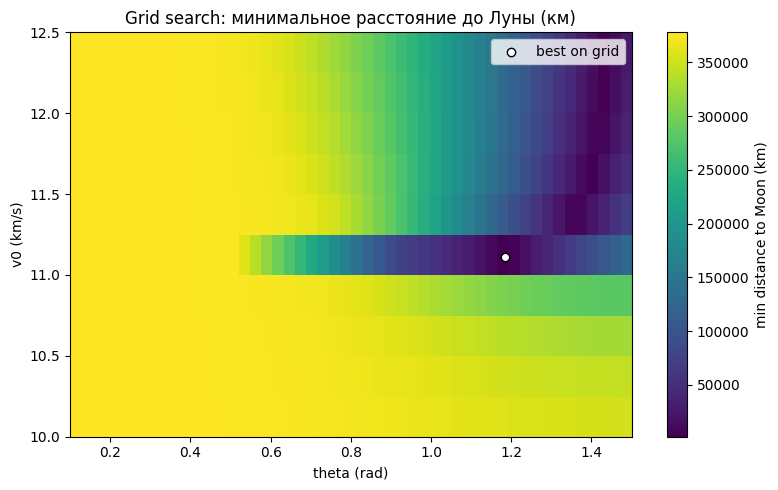

In [7]:
# визуализация heatmap (d_min в км)
plt.figure(figsize=(8,5))
im = plt.imshow(results/1e3, origin='lower', aspect='auto',
                extent=(theta_vals[0], theta_vals[-1], v0_vals[0]/1e3, v0_vals[-1]/1e3))
plt.colorbar(im, label='min distance to Moon (km)')
plt.scatter([best['theta']], [best['v0']/1e3], color='white', edgecolor='k', zorder=10, label='best on grid')
plt.xlabel('theta (rad)'); plt.ylabel('v0 (km/s)')
plt.title('Grid search: минимальное расстояние до Луны (км)')
plt.legend(); plt.tight_layout()


In [8]:
v0_star = best['v0']
if v0_star is not None:
    f_obj = lambda th: objective_theta(th, v0_star) if (0.0 < th < np.pi/2) else 1e20
    res = minimize_scalar(lambda th: abs(f_obj(th)), bounds=(max(0.01, best['theta']-0.2), min(1.55, best['theta']+0.2)), method='bounded', options={'xatol':1e-4})
    print('Локальная минимизация |objective| при v0=%.1f -> theta=%.6f, |objective|=%.3e m' % (v0_star, res.x, res.fun))
    # проверим симуляцию для найденного theta
    out_refined = simulate_flight(res.x, v0_star, tmax=7*24*3600)
    print('Попадание в Луну?', out_refined['hit_moon'], 'Мин. расстояние (km)=', out_refined['d_min']/1e3)
else:
    print('Нет кандидата из grid-search — расширьте диапазоны v0 или theta.')


Локальная минимизация |objective| при v0=11111.1 -> theta=1.189722, |objective|=6.519e-09 m
Попадание в Луну? True Мин. расстояние (km)= 1737.4000000000065


In [9]:
phi_vals = np.linspace(0, 2*np.pi, 8)
best_phi = dict(d=np.inf, phi=None, v0=None, theta=None)
for phi in phi_vals:
    def moon_pos_phi(t, phi0=phi):
        return np.array([a_EM*np.cos(omega_m*t + phi0), a_EM*np.sin(omega_m*t + phi0)])
    moon_pos_backup = globals().get('moon_pos', None)
    globals()['moon_pos'] = lambda t, phi0=phi: moon_pos_phi(t, phi0)
    for v0 in [11000.0, 11500.0, 12000.0]:
        for th in np.linspace(0.5, 1.4, 12):
            try:
                out = simulate_flight(th, v0, tmax=5*24*3600)
                if out['d_min'] < best_phi['d']:
                    best_phi.update(d=out['d_min'], phi=phi, v0=v0, theta=th)
            except Exception:
                pass
    if moon_pos_backup is not None:
        globals()['moon_pos'] = moon_pos_backup

print('Лучший результат по фазе: phi=%.3f, v0=%.1f, theta=%.6f, d_min=%.3e m (%.1f km)' %
      (best_phi['phi'], best_phi['v0'], best_phi['theta'], best_phi['d'], best_phi['d']/1e3))


Лучший результат по фазе: phi=0.898, v0=11500.0, theta=0.827273, d_min=1.814e+06 m (1814.4 km)


Для поиска корня уравнения f(x) = 0 можно использовать различные методы от понятного метода Ньютона с касательными до более продвинутых, представленных в фреймворке scipy. Не буду врать, что идею использовать root_scalar из scipy, мне предложил ИИ, но я изучил документацию и понимаю как он устроен. Он нужен для поиска корня уравнения f(x) = 0  в одномерном случае, при это используется знание теоремы о промежуточном значении (передается кортеж bracket с значениями функциями f противоположных знаков). Про brentq: если функция непрерывна и на концах отрезка значения имеют разные знаки, то алгоритм гарантированно найдёт корень внутри отрезка. При этом он обычно быстрее, чем простая бисекция, потому что где возможно использует более умные приближения. Насчет greed search — это стандартный и самый простой метод поиска оптимального значения для какой то функции по сетке параметров, которые мы сами задаем. В моей реализации была двумерная сетка параметров theta и v0 и функция которую мы минизируем objective_theta. То есть мы проходимся по любой комбинации параметров theta и vo и ищем наилучшее значение нашей функции objective. В реальных более сложных исследованиях greed search используется не так часто, так как сетки параметров зачастую имеют огромную размерность пространства возможноных значений параметров. Я например в своих работах связанных с ML, DL использую optuna с байесовским оптимизатором TPE sampler. Но тут в нашей задаче обычного greed search было более чем достаточно. 